# ⚽ Projeto 2 — Quantos gols serão marcados? (Regressão)
### Prevendo o **placar** de jogos do futebol **feminino** com Machine Learning

**Para estudantes do ensino médio 🇧🇷**

---

No Projeto 1 previmos **quem vence** (uma categoria). Agora vamos prever um
**número**: **quantos gols** um time vai marcar. Prever um número se chama **regressão**.

No fim, vamos juntar a previsão de gols da casa e da visitante para **estimar o
placar** de um jogo — por exemplo, um jogo da Seleção Brasileira 🇧🇷.

### O que você vai aprender
1. A diferença entre **classificação** e **regressão**.
2. Como criar atributos de **ataque**, **defesa** e **forma recente**.
3. Como avaliar modelos de regressão com **MAE** e **RMSE**.
4. Um modelo feito para **contagens**: a **Regressão de Poisson** 🎯.
5. **Gols são números inteiros!** Será que **arredondar** a previsão melhora o erro?
6. Como prever um **placar** completo.

> ⚠️ **Importante:** usamos **somente jogos do futebol feminino**. Nenhum jogo
> masculino entra nesta análise.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Ferramentas e dados

Importamos as bibliotecas e carregamos a base de jogos femininos, sempre
**ordenada por data** (o tempo é essencial aqui!).

> 🔎 Repare em um modelo novo: o `PoissonRegressor`. A **distribuição de Poisson**
> é a matemática por trás de "quantas vezes um evento raro acontece num intervalo" —
> exatamente o caso de **gols numa partida**!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

url_csv = "https://raw.githubusercontent.com/martj42/womens-international-results/master/results.csv"

jogos = pd.read_csv(url_csv)
jogos["date"] = pd.to_datetime(jogos["date"])
jogos = jogos.sort_values("date").reset_index(drop=True)

print(f"{len(jogos)} jogos carregados, de {jogos['date'].min().date()} a {jogos['date'].max().date()}")
jogos.head()

11650 jogos carregados, de 1956-09-23 a 2026-06-10


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1956-09-23,Germany,Netherlands,2,1,Friendly,Essen,Germany,False
1,1957-07-28,Germany,England,1,1,Friendly,Stuttgart,Germany,False
2,1957-10-13,Germany,Netherlands,2,0,Friendly,Berlin,Germany,False
3,1957-11-03,Netherlands,Austria,8,1,European Championship,Berlin,Germany,True
4,1957-11-03,Germany,England,0,4,European Championship,Berlin,Germany,False


## 2. Quantos gols costumam ser marcados?

Vamos olhar a distribuição de gols do time da casa. Isso dá intuição do
"número típico" que o modelo terá que acertar — e mostra que os gols são sempre
**números inteiros** (0, 1, 2, 3...).

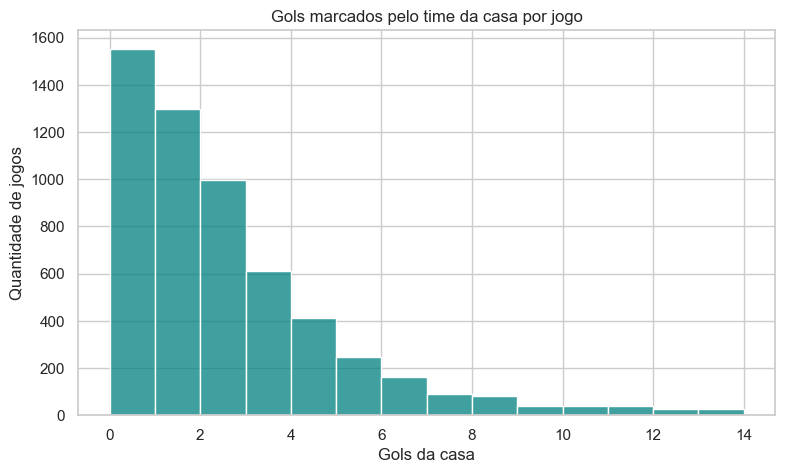

Média de gols da casa: 2.24
Repare: os gols só assumem valores INTEIROS (0, 1, 2, ...). Guarde essa ideia! 🧠


In [ ]:
plt.figure()
sns.histplot(jogos["home_score"], bins=range(0, 15), color="teal")
plt.title("Gols marcados pelo time da casa por jogo")
plt.xlabel("Gols da casa"); plt.ylabel("Quantidade de jogos")
plt.show()

print(f"Média de gols da casa: {jogos['home_score'].mean():.2f}")
print("Repare: os gols só assumem valores INTEIROS (0, 1, 2, ...). Guarde essa ideia! 🧠")

## 3. Engenharia de atributos ⚙️

Para prever **gols**, o modelo precisa de pistas sobre:

- 💪 a **força** de cada seleção → **rating Elo** (igual ao Projeto 1);
- 🔥 a **forma recente**: quantos gols cada time vem **marcando** e **sofrendo**.

### 3.1 Rating Elo (força geral)

In [ ]:
def calcular_elo(jogos, K=32, fator_casa=60, inicial=1500):
    # Calcula o Elo cronologicamente (sem usar o futuro).
    rating = {}
    elo_casa, elo_visit = [], []
    for _, j in jogos.iterrows():
        casa, visit = j["home_team"], j["away_team"]
        r_casa = rating.get(casa, inicial)
        r_visit = rating.get(visit, inicial)
        vantagem = 0 if j["neutral"] else fator_casa
        elo_casa.append(r_casa)
        elo_visit.append(r_visit)
        E = 1 / (1 + 10 ** (-((r_casa + vantagem) - r_visit) / 400))
        if j["home_score"] > j["away_score"]: S = 1.0
        elif j["home_score"] < j["away_score"]: S = 0.0
        else: S = 0.5
        rating[casa] = r_casa + K * (S - E)
        rating[visit] = r_visit + K * ((1 - S) - (1 - E))
    jogos = jogos.copy()
    jogos["elo_casa"] = elo_casa
    jogos["elo_visitante"] = elo_visit
    jogos["elo_diferenca"] = jogos["elo_casa"] - jogos["elo_visitante"]
    jogos["campo_neutro"] = jogos["neutral"].astype(int)
    return jogos, rating

jogos, rating_final = calcular_elo(jogos)
print("Elo calculado ✅")

Elo calculado ✅


### 3.2 Forma recente (médias móveis)

A **forma recente** mede a fase do time. Para cada jogo, calculamos a **média de
gols marcados e sofridos** por cada seleção nos seus **últimos 5 jogos**.

> 🔑 Usamos só os jogos **anteriores**: atualizamos o histórico **depois** de
> registrar as médias, evitando **vazamento de dados**.

In [ ]:
def forma_recente(jogos, n=5):
    # Para cada time, media de gols marcados/sofridos nos n jogos ANTERIORES.
    hist = {}   # time -> lista de (gols_marcados, gols_sofridos)
    gm_casa, gs_casa, gm_visit, gs_visit = [], [], [], []
    padrao = [(1.3, 1.3)]   # chute inicial p/ quem ainda nao tem historico

    for _, j in jogos.iterrows():
        casa, visit = j["home_team"], j["away_team"]
        hc = hist.get(casa, padrao)[-n:]
        hv = hist.get(visit, padrao)[-n:]
        gm_casa.append(np.mean([x[0] for x in hc]))
        gs_casa.append(np.mean([x[1] for x in hc]))
        gm_visit.append(np.mean([x[0] for x in hv]))
        gs_visit.append(np.mean([x[1] for x in hv]))
        # Atualiza o historico DEPOIS de registrar (sem vazamento)
        hist.setdefault(casa, []).append((j["home_score"], j["away_score"]))
        hist.setdefault(visit, []).append((j["away_score"], j["home_score"]))

    jogos = jogos.copy()
    jogos["casa_gols_marcados_media"]  = gm_casa
    jogos["casa_gols_sofridos_media"]  = gs_casa
    jogos["visit_gols_marcados_media"] = gm_visit
    jogos["visit_gols_sofridos_media"] = gs_visit
    return jogos

jogos = forma_recente(jogos, n=5)
jogos[["home_team","away_team","casa_gols_marcados_media","visit_gols_sofridos_media"]].tail()

,home_team,away_team,casa_gols_marcados_media,visit_gols_sofridos_media
5652,Japan,Sweden,3.4,0.2
5653,Australia,France,2.4,0.8
5654,England,Colombia,1.8,0.6
5655,Spain,Sweden,3.0,0.4
5656,Australia,England,1.8,0.4


## 4. Divisão treino/teste cronológica ⏳

Como no Projeto 1, respeitamos o tempo: treinamos com o **passado** (antes de 2019)
e testamos no **futuro** (2019 em diante). Nunca o contrário!

In [ ]:
atributos = [
    "elo_casa", "elo_visitante", "elo_diferenca", "campo_neutro",
    "casa_gols_marcados_media", "casa_gols_sofridos_media",
    "visit_gols_marcados_media", "visit_gols_sofridos_media",
]

corte = pd.Timestamp("2019-01-01")
treino = jogos[jogos["date"] < corte]
teste  = jogos[jogos["date"] >= corte]

X_treino = treino[atributos]
X_teste  = teste[atributos]
y_treino = treino["home_score"]   # ALVO: gols da casa
y_teste  = teste["home_score"]

print(f"Treino: {len(treino)} jogos | Teste: {len(teste)} jogos")

Treino: 4560 jogos | Teste: 1097 jogos


## 5. Como medir o erro? MAE e RMSE

Em regressão não usamos "acurácia". Medimos **o quão longe** a previsão ficou do real:

- **MAE** (Erro Absoluto Médio): em média, erramos por quantos gols? *(fácil de entender)*
- **RMSE**: parecido, mas **pune mais** os erros grandes.

Em ambos, **quanto menor, melhor**. Começamos com um **baseline**: prever sempre a
**média de gols** do treino.

In [ ]:
def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

media_gols = y_treino.mean()
palpite_baseline = np.full(len(y_teste), media_gols)

mae_base  = mean_absolute_error(y_teste, palpite_baseline)
rmse_base = rmse(y_teste, palpite_baseline)
print(f"Baseline (prever sempre {media_gols:.2f} gols):")
print(f"  MAE  = {mae_base:.3f}")
print(f"  RMSE = {rmse_base:.3f}")

Baseline (prever sempre 2.28 gols):
  MAE  = 1.877
  RMSE = 2.549


## 6. Treinando os modelos de regressão 🤖

Comparamos **quatro** modelos:

1. **Regressão Linear** — traça a "melhor reta" entre atributos e gols.
2. **Random Forest** — combina muitas árvores de decisão.
3. **Gradient Boosting** — árvores que corrigem os erros umas das outras.
4. **Regressão de Poisson** 🎯 — um modelo **feito para contagens** (número de gols,
   número de e-mails por hora, número de clientes numa fila...). Ele nunca prevê
   valores negativos e "entende" que estamos contando eventos.

In [ ]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Poisson (contagem)": PoissonRegressor(max_iter=500),
}

resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    prev = modelo.predict(X_teste)
    resultados[nome] = {"mae": mean_absolute_error(y_teste, prev), "rmse": rmse(y_teste, prev)}
    print(f"{nome:20s} -> MAE {resultados[nome]['mae']:.3f} | RMSE {resultados[nome]['rmse']:.3f}")

print(f"\n{'Baseline':20s} -> MAE {mae_base:.3f} | RMSE {rmse_base:.3f}")

Regressão Linear     -> MAE 1.479 | RMSE 2.040
Random Forest        -> MAE 1.444 | RMSE 2.046
Gradient Boosting    -> MAE 1.333 | RMSE 1.926
Poisson (contagem)   -> MAE 1.467 | RMSE 2.116

Baseline             -> MAE 1.877 | RMSE 2.549


C:\Users\xx-re\AppData\Local\Temp\ipykernel_21328\1102334820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=nomes, y=maes, palette="crest")


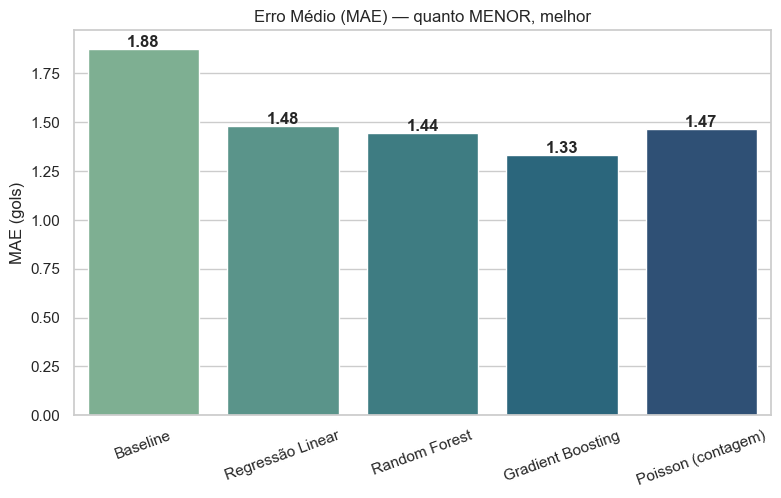

In [ ]:
nomes = ["Baseline"] + list(resultados.keys())
maes  = [mae_base] + [resultados[n]["mae"] for n in resultados]

plt.figure()
barras = sns.barplot(x=nomes, y=maes, palette="crest")
for i, v in enumerate(maes):
    barras.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
plt.title("Erro Médio (MAE) — quanto MENOR, melhor")
plt.ylabel("MAE (gols)"); plt.xticks(rotation=20)
plt.show()

💡 Todos os modelos de ML **erram menos** que o baseline. Aqui o **Gradient
Boosting** costuma ganhar.

Curiosidade: o modelo de **Poisson** é o mais "correto" na teoria para contar gols,
mas **não é automaticamente o melhor** nestes dados — na prática, sempre vale a pena
**testar e comparar** em vez de confiar só na teoria! 🔬

## 7. ⚽ Gols são inteiros: vale a pena **arredondar**?

Você teve uma ótima ideia: como **gols são números inteiros** (não existe "2,3 gols"
numa partida!), talvez **arredondar** a previsão para o inteiro mais próximo melhore o erro.

Vamos **testar de verdade**. Para cada modelo, comparamos:
- a previsão **contínua** (ex.: 2,31);
- a previsão **arredondada** para o inteiro mais próximo (ex.: 2), nunca abaixo de 0.

> 🧪 **Método científico:** não vamos só *achar* — vamos **medir** o MAE e o RMSE
> das duas versões e olhar os números.

In [ ]:
def arredondar_gols(pred):
    # Arredonda para o inteiro mais proximo e impede gols negativos.
    return np.clip(np.round(pred), 0, None)

linhas = []
for nome, modelo in modelos.items():
    pred = modelo.predict(X_teste)
    pred_int = arredondar_gols(pred)
    linhas.append({
        "Modelo": nome,
        "MAE contínuo":   mean_absolute_error(y_teste, pred),
        "MAE arredondado": mean_absolute_error(y_teste, pred_int),
        "RMSE contínuo":   rmse(y_teste, pred),
        "RMSE arredondado": rmse(y_teste, pred_int),
    })

tabela = pd.DataFrame(linhas).set_index("Modelo").round(3)
tabela

,MAE contínuo,MAE arredondado,RMSE contínuo,RMSE arredondado
Modelo,,,,
Regressão Linear,1.479,1.398,2.040,2.029
Random Forest,1.444,1.423,2.046,2.060
Gradient Boosting,1.333,1.316,1.926,1.950
Poisson (contagem),1.467,1.469,2.116,2.139


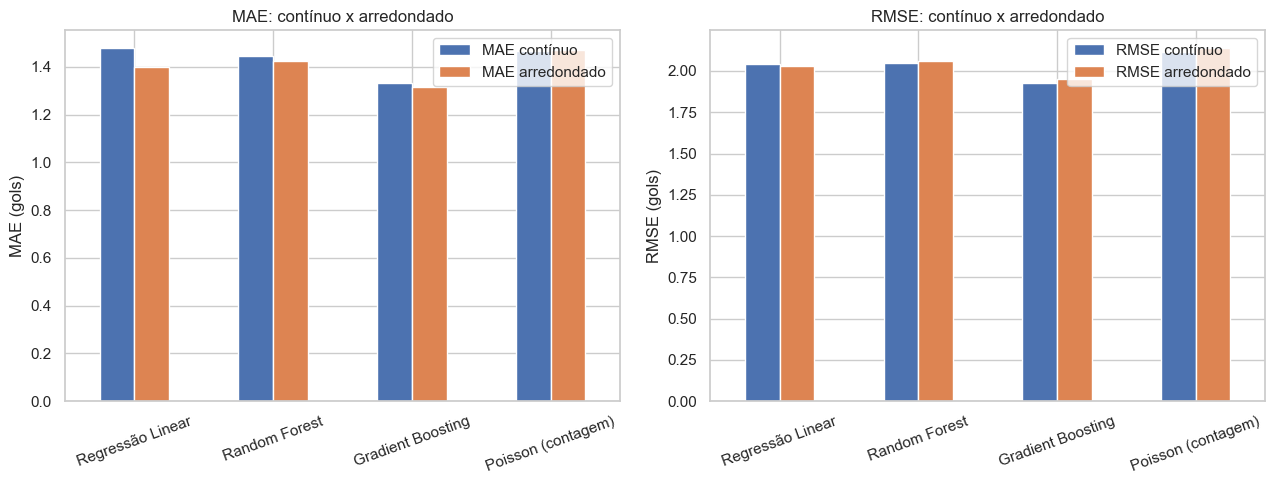

In [ ]:
# Grafico: MAE continuo x arredondado (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

comp_mae = tabela[["MAE contínuo", "MAE arredondado"]]
comp_mae.plot(kind="bar", ax=ax1, color=["#4c72b0", "#dd8452"])
ax1.set_title("MAE: contínuo x arredondado")
ax1.set_ylabel("MAE (gols)"); ax1.set_xlabel(""); ax1.tick_params(axis="x", rotation=20)

comp_rmse = tabela[["RMSE contínuo", "RMSE arredondado"]]
comp_rmse.plot(kind="bar", ax=ax2, color=["#4c72b0", "#dd8452"])
ax2.set_title("RMSE: contínuo x arredondado")
ax2.set_ylabel("RMSE (gols)"); ax2.set_xlabel(""); ax2.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

### 🔎 O que os números nos ensinam

Olhando a tabela e os gráficos, aparece um padrão muito interessante:

- ✅ **Arredondar quase sempre MELHORA o MAE.** Faz sentido: como os valores reais
  são inteiros, "cravar" o número inteiro mais provável reduz o erro médio.
- ⚠️ **Arredondar costuma PIORAR um pouco o RMSE.** Por quê? O RMSE é minimizado pela
  **média**, e o modelo já entrega a melhor média possível. Ao arredondar, nós nos
  afastamos dessa média — e como o RMSE **pune erros grandes ao quadrado**, ele sobe
  um pouquinho.

> 🧠 **Grande lição:** *"melhor" depende da métrica que você escolhe!* Se o seu
> objetivo é acertar o **placar inteiro** (o número de gols), arredondar é ótimo e
> o **MAE** é a métrica certa para acompanhar. Não existe uma resposta única — existe
> a resposta certa **para o seu objetivo**. Sua intuição estava certíssima para o MAE! 🎯

## 8. Prevendo um **placar** completo 🇧🇷

Até aqui previmos os gols do **time da casa**. Para estimar um **placar**, treinamos
um segundo modelo para os gols do **time visitante** e juntamos os dois — agora
mostrando o resultado em **gols inteiros**, como num placar de verdade.

In [ ]:
# Escolhemos o melhor modelo pelo MAE arredondado (nosso objetivo: acertar o placar)
melhor_nome = tabela["MAE arredondado"].idxmin()
print(f"Melhor modelo para o placar (menor MAE arredondado): {melhor_nome}")

modelo_casa = modelos[melhor_nome]                        # ja treinado p/ gols da casa
modelo_visit = type(modelo_casa)(**modelo_casa.get_params())
modelo_visit.fit(X_treino, treino["away_score"])

def prever_placar(time_casa, time_visitante, neutro=False, n=5):
    # Monta a linha de atributos para um jogo hipotetico com os dados mais recentes.
    elo_c = rating_final.get(time_casa, 1500)
    elo_v = rating_final.get(time_visitante, 1500)

    def ultimas_medias(time):
        h = jogos[(jogos.home_team == time) | (jogos.away_team == time)].tail(n)
        gm = np.mean([(r.home_score if r.home_team == time else r.away_score) for _, r in h.iterrows()])
        gs = np.mean([(r.away_score if r.home_team == time else r.home_score) for _, r in h.iterrows()])
        return gm, gs

    gm_c, gs_c = ultimas_medias(time_casa)
    gm_v, gs_v = ultimas_medias(time_visitante)

    linha = pd.DataFrame([{
        "elo_casa": elo_c, "elo_visitante": elo_v,
        "elo_diferenca": elo_c - elo_v, "campo_neutro": int(neutro),
        "casa_gols_marcados_media": gm_c, "casa_gols_sofridos_media": gs_c,
        "visit_gols_marcados_media": gm_v, "visit_gols_sofridos_media": gs_v,
    }])[atributos]

    # Expectativa (continua) e placar arredondado (inteiro)
    exp_casa  = float(modelo_casa.predict(linha)[0])
    exp_visit = float(modelo_visit.predict(linha)[0])
    gols_casa  = int(arredondar_gols(exp_casa))
    gols_visit = int(arredondar_gols(exp_visit))
    return exp_casa, exp_visit, gols_casa, gols_visit

print()
for adv in ["United States", "Argentina", "Germany", "Nigeria"]:
    ec, ev, gc, gv = prever_placar("Brazil", adv)
    print(f"🇧🇷 Brasil {gc} x {gv} {adv}    (expectativa de gols: {ec:.1f} x {ev:.1f})")

Melhor modelo para o placar (menor MAE arredondado): Gradient Boosting

🇧🇷 Brasil 1 x 2 United States    (expectativa de gols: 0.7 x 1.9)
🇧🇷 Brasil 2 x 1 Argentina    (expectativa de gols: 2.4 x 0.5)
🇧🇷 Brasil 1 x 2 Germany    (expectativa de gols: 0.8 x 1.7)
🇧🇷 Brasil 2 x 1 Nigeria    (expectativa de gols: 1.7 x 0.7)


> 🧠 **Como ler isso:** agora o **placar** aparece em gols inteiros (ex.: "Brasil 2 x 1"),
> que é como um resultado real. Entre parênteses deixamos a **expectativa de gols**
> (com casas decimais) — ela mostra a *confiança* do modelo. "2,4 x 0,5" indica uma
> vitória mais tranquila do que "2,4 x 1,9". Lembre-se: é uma **estimativa**, não uma
> certeza!

## 9. Exercícios para você continuar 🚀

1. **Mude o número de jogos** da forma recente (`n=5` → `n=3` ou `n=10`). O MAE melhora?
2. **Preveja o total de gols** (`home_score + away_score`) em vez dos gols da casa.
   O arredondamento ajuda mais ou menos nesse caso?
3. Compare **arredondar** com **truncar** (arredondar sempre para baixo, `np.floor`).
   Qual dá o menor MAE?
4. Use `prever_placar` para simular uma **Copa do Mundo Feminina** entre suas
   seleções favoritas 🏆.
5. **Pesquise:** o modelo de **Poisson** / *Dixon-Coles* pode dar a **probabilidade
   de cada placar** (ex.: 35% de chance de 2x1). Como isso é diferente de prever um
   único número?

> **Reflexão final:** um modelo nunca vai "cravar" o placar exato — o futebol tem
> sorte, azar e emoção. Mas você aprendeu algo poderoso: **a escolha da métrica muda
> qual modelo é o "melhor"**. Arredondar ganhou no MAE porque gols são inteiros — e
> saber *por que* é o que separa quem usa ML de quem realmente entende ML. ⚽📊
